In [27]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send
from typing import TypedDict, List, Annotated
from operator import add
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [28]:
class OverallState(TypedDict):
    research_topic: str
    sources: List[str]
    worker_findings: Annotated[List[dict], add]
    final_report: str

In [29]:
class WorkerState(TypedDict):
    source: str
    worker_id: int
    research_topic: str

In [30]:
class ResearchPlan(BaseModel):
    sources: List[str] = Field(
        description="List of specific research sources/aspects to investigate",
        max_length=5
    )
    reasoning: str = Field(
        description="Brief explanation of why these sources where chosen"
    )

In [31]:
model = ChatGoogleGenerativeAI(model = "gemini-3.5-flash-lite",
                                max_tokens = 512,)

## Orchestrator (Breakdown The Task Into Subtasks)

In [32]:
def plan_research(state: OverallState) -> OverallState:

    print("\n" + "="*70)
    print("🤖 ORCHESTRATOR: Planning research strategy")
    print("="* 70)
    print(f"Topic: {state['research_topic']}\n")

    planner_llm = model.with_structured_output(ResearchPlan)

    prompt = f"""You are a research strategist planning a comprehensive investigation.

    Research Topic: {state['research_topic']}

    CRITICAL INSTRUCTION: Generate between 3-5 specific research sources or aspects to investigate. 
    DO NOT generate more than 5 sources.

    Each source should be:
    - Specific and focused on a distinct aspect
    - Relevant to the overall topic
    - Complementary to other sources (minimal overlap)
    - Concrete enough to guide targeted research

    Examples of good sources:
    - "Clinical trial results and efficacy data"
    - "Economic impact and cost-benefit analysis"
    - "Regulatory framework and compliance requirements"
    - "Patient outcomes and quality of life metrics"
    - "Industry adoption rates and market trends"

    Generate sources that will provide comprehensive coverage of the topic."""

    research_plan = planner_llm.invoke(prompt)

    print(f"Orchestrator generated {len(research_plan.sources)} research sources")

    for i, source in enumerate(research_plan.sources, 1):
        print(f"{i}. {source}")

    print(f"\n💡 Reasoning: {research_plan.reasoning}")
    print("Preparing to dispatch to nodes...")

    return {
        "sources": research_plan.sources
    }

## Worker Node (Receive It's Task From Orchestrator)

In [33]:
def research_worker(state: WorkerState) -> OverallState:

    worker_id = state["worker_id"]
    source = state["source"]

    print(f"🔍 WORKER {worker_id}: Researching '{source}'...")

    prompt = f"""You are a specialized researcher investigating: {state['research_topic']}

    Your specific focus area: {source}

    Conduct thorough research on this aspect and provide:

    1. KEY FINDINGS (3-5 specific points)
    - What are the most important discoveries or facts?
    
    2. DATA & STATISTICS
    - Relevant numbers, percentages, or quantitative information
    
    3. INSIGHTS & ANALYSIS
    - What does this information mean?
    - How does it relate to the broader topic?
    
    4. SOURCES & CREDIBILITY
    - Types of sources you would consult (academic, industry, government, etc.)
    
    5. IMPLICATIONS
    - Why does this matter for understanding the overall topic?

    Be specific, factual, and provide depth on this particular aspect."""

    response = model.invoke(prompt).content

    findings = {
        "worker_id": worker_id,
        "source": source,
        "content": response
    }

    print(f"✅ WORKER {worker_id}: Research Complete\n")

    return {
        "worker_findings": [findings]
    }

## Synthesizer (Combine All Workers Tasks After Finish It)

In [34]:
def synthesize_report(state: OverallState) -> OverallState:
    print("="*70)
    print("📝 SYNTHESIZER: Combining insights from all workers")
    print("="*70)

    print(f"Processing findings from {len(state['worker_findings'])} research sources")

    all_findings = "\n\n" + "="* 70 + "\n\n"
    all_findings += "\n\n".join([
        f"RESEARCH AREA {f['worker_id']}: {f['source']}\n{'-'*70}\n{f['content']}" for f in state["worker_findings"]
    ])

    prompt = f"""You are synthesizing a comprehensive research report on: {state['research_topic']}

    You have received detailed findings from {len(state['worker_findings'])} specialized researchers, 
    each investigating a different aspect of this topic.

    RESEARCH FINDINGS:
    {all_findings}

    Create a cohesive, well-structured research report (500-700 words) with the following sections:

    1. EXECUTIVE SUMMARY (2-3 sentences)
    - Provide a high-level overview of the key takeaways

    2. INTRODUCTION
    - Context and importance of this topic
    - Scope of this research

    3. KEY FINDINGS
    - Integrate insights from all research areas
    - Organize thematically rather than by source
    - Use specific data and examples

    4. ANALYSIS & SYNTHESIS
    - Identify patterns across different research areas
    - Highlight connections and relationships
    - Note any contradictions or tensions

    5. IMPLICATIONS
    - What do these findings mean?
    - Who is affected and how?

    6. CONCLUSIONS
    - Main takeaways
    - Areas for further research

    IMPORTANT: 
    - Write this as a unified, flowing report, NOT as separate sections from each researcher
    - Integrate findings naturally across themes
    - Use specific examples and data from the research
    - Make it professional and authoritative"""

    final_report = model.invoke(prompt).content

    print("✅ SYNTHESIZER: Final report Complete\n")

    return {
        "final_report": final_report
    }

## Conditional Edge Function

In [35]:
def create_research_workers(state: OverallState):

    print("🚏 DISPATCHER: Creating research workers dynamically...")

    return [
        Send("research_worker", {
            "source": source,
            "worker_id": i + 1,
            "research_topic": state["research_topic"]
        })
        for i, source in enumerate(state["sources"])
    ]

## Build Graph

In [36]:
builder = StateGraph(OverallState)

builder.add_node("orchestrator", plan_research)
builder.add_node("research_worker", research_worker)
builder.add_node("synthesizer", synthesize_report)

builder.add_edge(START, "orchestrator")

builder.add_conditional_edges(
    "orchestrator",
    create_research_workers,
    ["research_worker"]
)

builder.add_edge("research_worker", "synthesizer")
builder.add_edge("synthesizer", END)

graph = builder.compile()

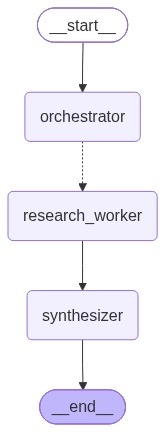

In [37]:
graph

In [38]:
healthcare_topic = "The impact of artificial intelligence on healthcare delivery and patient outcomes"
environmental_topic = "Renewable energy adoption barriers in developing countries"

topic = environmental_topic

print("="*70)
print(f"Topic: {topic}")
print("="*70)

result = graph.invoke({
    "research_topic": topic,
    "sources": [],
    "worker_findings": []
})

print("="*70)
print(f"FINAL SYNTHESIZED RESULT")
print("="*70)
print(result["final_report"])

Topic: Renewable energy adoption barriers in developing countries

🤖 ORCHESTRATOR: Planning research strategy
Topic: Renewable energy adoption barriers in developing countries

Orchestrator generated 5 research sources
1. Financial constraints and initial capital investment costs
2. Regulatory frameworks and government subsidy policies
3. Grid infrastructure limitations and technological readiness
4. Local workforce skills and technical training availability
5. Social acceptance and community-level cultural barriers

💡 Reasoning: These five distinct aspects cover the core dimensions of renewable energy adoption barriers in developing nations, ranging from economics and policy to infrastructure, labor, and sociology, ensuring a comprehensive investigation without redundancy.
Preparing to dispatch to nodes...
🚏 DISPATCHER: Creating research workers dynamically...
🔍 WORKER 1: Researching 'Financial constraints and initial capital investment costs'...
🔍 WORKER 2: Researching 'Regulatory fr

In [44]:
print(result["final_report"][0]['text'])

# Comprehensive Research Report: Renewable Energy Adoption Barriers in Developing Countries

### 1. Executive Summary
Accelerating renewable energy adoption in the Global South is critical for global climate mitigation, yet developing nations face a complex matrix of systemic roadblocks. These barriers—spanning prohibitive capital costs, regressive subsidies, fragile grid architectures, technical skill shortages, and severe cultural friction—create a compounding crisis that stifles clean energy transitions. Overcoming these hurdles requires a holistic policy framework that aligns financial incentives, modernizes grid infrastructure, and prioritizes community-led development.

### 2. Introduction
As the existential threat of climate change intensifies, the transition from fossil fuels to renewable energy in developing countries has become paramount. However, despite vast natural endowments of solar, wind, and geothermal resources, the pace of adoption in emerging economies lags drastica